In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("results.txt", names=["n", "q", "runtime"])

summary = (
    df.groupby(["n", "q"], as_index=False)
      .agg(mean_runtime=("runtime", "mean"))
)

def expected_runtime(n, q, c=1.0):
    inner = np.exp((2 * c * (q - 1) * (np.sin(np.pi / q) ** 2)) / q) - 1
    return (q ** n) * (1 + 1 / inner)

def upper_bound(n, q, c=1.0):
    return (q ** (n + 2)) * (1 / (4 * c) + 1 / (q ** 2))

summary["expected_runtime"] = summary.apply(
    lambda row: expected_runtime(row["n"], row["q"], c=1.0), axis=1
)

summary["upper_bound"] = summary.apply(
    lambda row: upper_bound(row["n"], row["q"], c=1.0), axis=1
)

summary["mean_runtime_over_expected_runtime"] = (
    summary["mean_runtime"] / summary["expected_runtime"]
)

summary["mean_runtime_over_upper_bound"] = (
    summary["mean_runtime"] / summary["upper_bound"]
)

summary = summary[
    [
        "n",
        "q",
        "mean_runtime",
        "expected_runtime",
        "upper_bound",
        "mean_runtime_over_expected_runtime",
        "mean_runtime_over_upper_bound",
    ]
].sort_values(["q", "n"])

for q in sorted(summary["q"].unique()):
    print(f"\nq = {q}")
    print(
        summary[summary["q"] == q].to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


q = 2
 n  q  mean_runtime  expected_runtime  upper_bound  mean_runtime_over_expected_runtime  mean_runtime_over_upper_bound
 5  2       45.6700           50.6233      64.0000                              0.9022                         0.7136
 6  2       81.7300          101.2465     128.0000                              0.8072                         0.6385
 7  2      206.3400          202.4930     256.0000                              1.0190                         0.8060
 8  2      399.9400          404.9860     512.0000                              0.9875                         0.7811
 9  2      774.4000          809.9721    1024.0000                              0.9561                         0.7562
10  2     1911.1700         1619.9441    2048.0000                              1.1798                         0.9332
11  2     3166.2400         3239.8883    4096.0000                              0.9773                         0.7730
12  2     5883.9800         6479.7766    8192.000

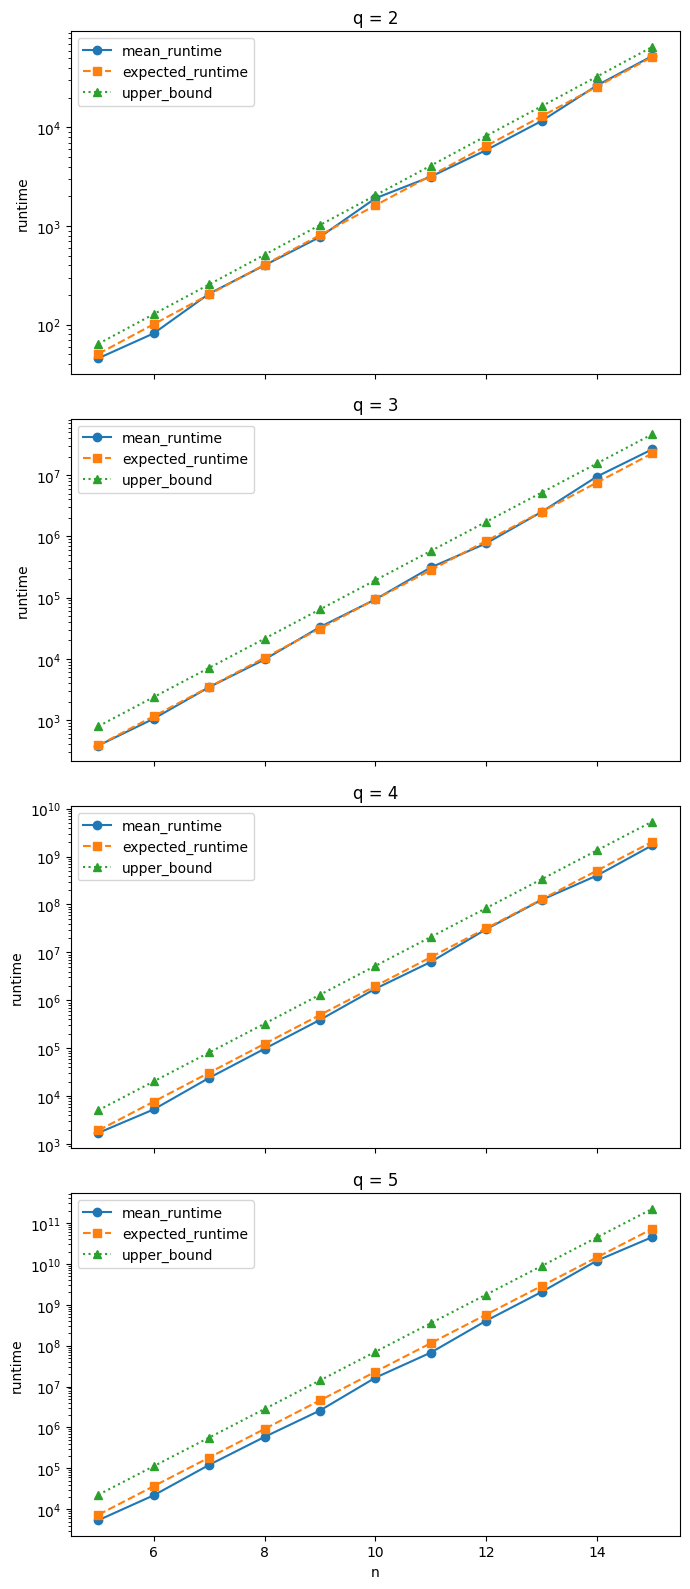

In [17]:
qs = sorted(summary["q"].unique())
fig, axes = plt.subplots(len(qs), 1, figsize=(7, 4 * len(qs)), sharex=True)

if len(qs) == 1:
    axes = [axes]

for ax, q in zip(axes, qs):
    sub = summary[summary["q"] == q].sort_values("n")
    ax.plot(sub["n"], sub["mean_runtime"], marker="o", label="mean_runtime")
    ax.plot(sub["n"], sub["expected_runtime"], marker="s", linestyle="--", label="expected_runtime")
    ax.plot(sub["n"], sub["upper_bound"], marker="^", linestyle=":", label="upper_bound")
    ax.set_title(f"q = {q}")
    ax.set_yscale("log")
    ax.set_ylabel("runtime")
    ax.legend()

axes[-1].set_xlabel("n")
plt.tight_layout()
plt.show()